In [1]:
import pandas as pd

In [13]:
spike_count_stats = pd.read_csv("spike_count_counts.csv")
time_window_stats = pd.read_csv("time_window_counts.csv")
timesurface_stats = pd.read_csv("timesurface_counts.csv")

In [14]:
spike_count_stats.head()

,representation,max_frame_count,min_frame_count,running_mean_frame_count,504,579,671,726,865,739,...,1156,326,1020,834,1356,274,1151,901,371,209
0,spike_count,1594,209,372.607399,4,11,8,3,2,4,...,1,1,1,1,1,2,1,1,1,1


In [15]:
time_window_stats.head()

,representation,max_frame_count,min_frame_count,running_mean_frame_count,504,579,671,726,865,739,...,493,324,910,805,909,801,846,357,462,679
0,time_window,1845,610,686.818394,4,10,8,3,1,4,...,1,1,1,1,1,1,2,1,1,1


In [16]:
timesurface_stats.head()

,representation,max_frame_count,min_frame_count,running_mean_frame_count,504,579,671,726,865,739,...,1156,326,1020,834,1356,274,1151,901,371,209
0,timesurface,1845,610,686.818394,8,21,16,6,3,8,...,1,1,1,1,1,2,1,1,1,1


In [17]:
spike_count_frequencies = spike_count_stats.drop(columns=["representation", "max_frame_count", "min_frame_count", "running_mean_frame_count"])
time_window_frequencies = time_window_stats.drop(columns=["representation", "max_frame_count", "min_frame_count", "running_mean_frame_count"])
timesurface_frequencies = timesurface_stats.drop(columns=["representation", "max_frame_count", "min_frame_count", "running_mean_frame_count"])


In [18]:
spike_count_histogram = spike_count_frequencies.iloc[0]
spike_count_hist_dict = spike_count_histogram.to_dict()
spike_count_hist_dict

{'504': 4,
 '579': 11,
 '671': 8,
 '726': 3,
 '865': 2,
 '739': 4,
 '822': 3,
 '677': 8,
 '664': 6,
 '646': 7,
 '659': 7,
 '508': 5,
 '616': 9,
 '793': 1,
 '630': 8,
 '1194': 1,
 '690': 6,
 '755': 4,
 '652': 6,
 '813': 2,
 '633': 6,
 '769': 4,
 '496': 3,
 '445': 2,
 '283': 1,
 '552': 6,
 '1216': 1,
 '619': 3,
 '673': 4,
 '660': 6,
 '665': 8,
 '658': 4,
 '543': 6,
 '478': 4,
 '668': 11,
 '647': 10,
 '541': 9,
 '794': 7,
 '737': 5,
 '830': 1,
 '588': 4,
 '750': 7,
 '686': 5,
 '880': 1,
 '662': 4,
 '692': 4,
 '840': 4,
 '1063': 1,
 '989': 2,
 '753': 2,
 '923': 2,
 '670': 7,
 '741': 3,
 '571': 7,
 '674': 7,
 '483': 9,
 '532': 4,
 '699': 6,
 '740': 5,
 '719': 7,
 '558': 4,
 '550': 4,
 '490': 6,
 '458': 3,
 '553': 3,
 '650': 3,
 '563': 5,
 '547': 6,
 '656': 6,
 '523': 6,
 '566': 5,
 '582': 4,
 '778': 2,
 '722': 3,
 '672': 5,
 '709': 6,
 '701': 6,
 '589': 6,
 '443': 4,
 '575': 7,
 '410': 3,
 '682': 5,
 '583': 4,
 '626': 4,
 '606': 6,
 '485': 3,
 '742': 7,
 '632': 4,
 '642': 2,
 '949': 2,
 '68

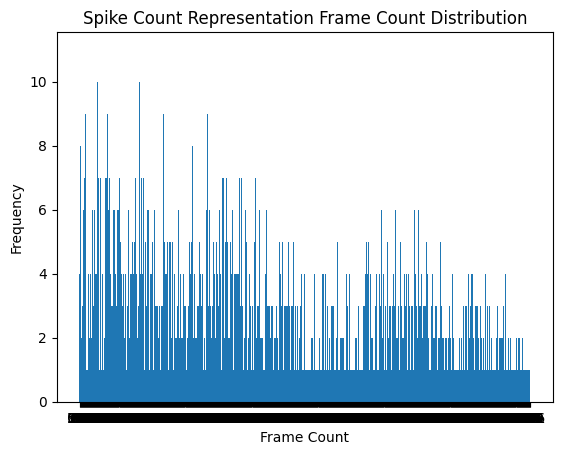

In [61]:
import matplotlib.pyplot as plt

plt.bar(spike_count_hist_dict.keys(), spike_count_hist_dict.values(), width=1.0)
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.title("Spike Count Representation Frame Count Distribution")
plt.show()

In [68]:
import numpy as np

spike_count_frame_counts = np.repeat(
    spike_count_histogram.index.astype(int).values,
    spike_count_histogram.values
)
p90_spike_count = np.percentile(spike_count_frame_counts, 90)
p95_spike_count = np.percentile(spike_count_frame_counts, 95)

print("90th percentile normally:", p90_spike_count)
print("95th percentile normally:", p95_spike_count)

90th percentile normally: 800.9000000000001
95th percentile normally: 906.8999999999996


In [20]:
import numpy as np

binned = spike_count_histogram.groupby(np.round(spike_count_histogram.index.astype(float) / 10) * 10).sum()
binned.index = binned.index.astype(int)

print(binned)

40       5
50       4
60      13
70      19
80      22
        ..
1490     1
1520     1
1560     1
1590     1
1840     1
Name: 0, Length: 132, dtype: int64


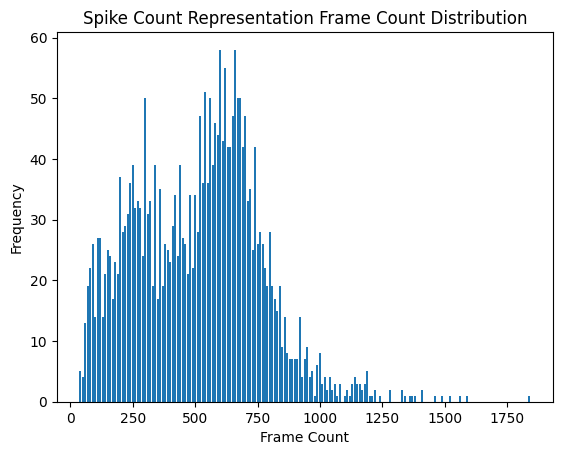

In [54]:
plt.bar(binned.index, binned.values, width=8)
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.title("Spike Count Representation Frame Count Distribution")
plt.show()

In [55]:
binned = binned.sort_values(ascending=False)
binned

660     58
600     58
620     55
540     51
300     50
        ..
1200     1
1120     1
1100     1
1070     1
1840     1
Name: 0, Length: 132, dtype: int64

In [22]:
print(len(binned))

132


In [ ]:
spike_count_frame_counts_binned = np.repeat(
    binned.index.astype(int).values,
    binned.values
)
p90_spike_count_binned = np.percentile(spike_count_frame_counts_binned, 90)
p95_spike_count_binned = np.percentile(spike_count_frame_counts_binned, 95)

print("90th percentile binned with 10:", p90_spike_count_binned)
print("95th percentile binned with 10:", p95_spike_count_binned)

90th percentile binned with 10: 800.0
95th percentile binned with 10: 909.4999999999982


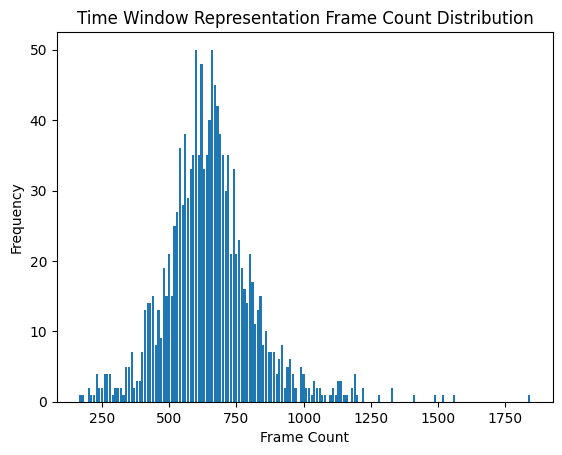

In [56]:
time_window_histogram = time_window_frequencies.iloc[0]
time_window_hist_dict = time_window_histogram.to_dict()
binned_time_window = time_window_histogram.groupby(np.round(time_window_histogram.index.astype(float) / 10) * 10).sum()
binned_time_window.index = binned_time_window.index.astype(int)
plt.bar(binned_time_window.index, binned_time_window.values, width=8)
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.title("Time Window Representation Frame Count Distribution")
plt.show()

In [57]:
binned_time_window = binned_time_window.sort_values(ascending=False)
binned_time_window

660     50
600     50
620     48
670     45
680     42
        ..
330      1
290      1
220      1
210      1
1840     1
Name: 0, Length: 108, dtype: int64

In [ ]:
time_window_frame_counts_binned = np.repeat(
    binned_time_window.index.astype(int).values,
    binned_time_window.values
)
p90_time_window_binned = np.percentile(time_window_frame_counts_binned, 90)
p95_time_window_binned = np.percentile(time_window_frame_counts_binned, 95)

print("90th percentile binned with 10:", p90_time_window_binned)
print("95th percentile binned with 10:", p95_time_window_binned)

90th percentile binned with 10: 840.0
95th percentile binned with 10: 940.0


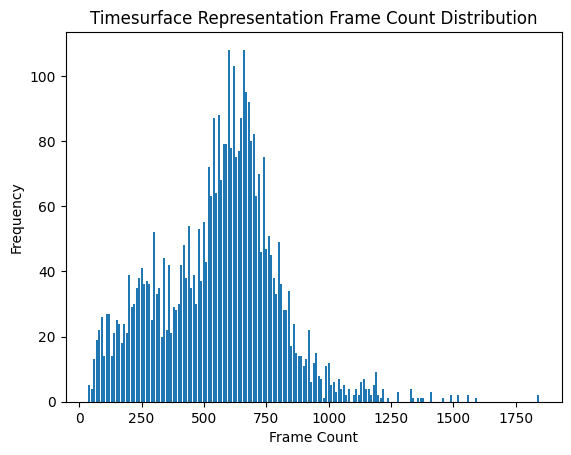

In [58]:
timsurface_histogram = timesurface_frequencies.iloc[0]
timsurface_hist_dict = timsurface_histogram.to_dict()
binned_timsurface = timsurface_histogram.groupby(np.round(timsurface_histogram.index.astype(float) / 10) * 10).sum()
binned_timsurface.index = binned_timsurface.index.astype(int)
plt.bar(binned_timsurface.index, binned_timsurface.values, width=8)
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.title("Timesurface Representation Frame Count Distribution")
plt.show()

In [60]:
binned_timsurface = binned_timsurface.sort_values(ascending=False)
binned_timsurface

660     108
600     108
620     103
670      95
680      92
       ... 
1460      1
1240      1
1210      1
1590      1
1370      1
Name: 0, Length: 132, dtype: int64

In [71]:
timesurface_frame_counts_binned = np.repeat(
    binned_timsurface.index.astype(int).values,
    binned_timsurface.values
)
p90_timesurface_binned = np.percentile(timesurface_frame_counts_binned, 90)
p95_timesurface_binned = np.percentile(timesurface_frame_counts_binned, 95)

print("90th percentile binned with 10:", p90_timesurface_binned)
print("95th percentile binned with 10:", p95_timesurface_binned)

90th percentile binned with 10: 820.0
95th percentile binned with 10: 920.0


In [27]:
binned.values.sum()

2682

In [28]:
binned_time_window.values.sum()

1341

In [29]:
binned_timsurface.values.sum()

4023

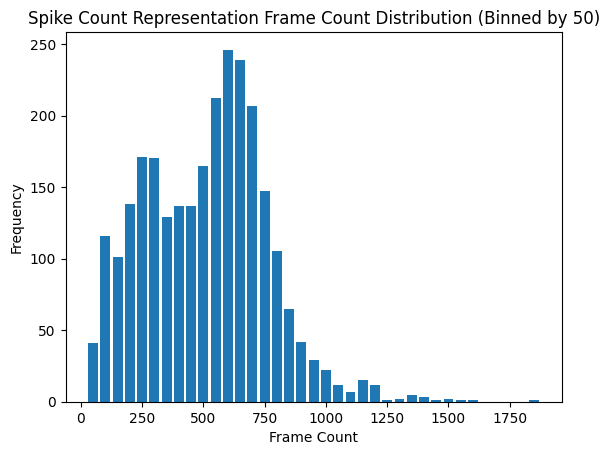

In [49]:
binned2_spike_count = spike_count_histogram.groupby(np.round(spike_count_histogram.index.astype(float) / 50) * 50).sum()
binned2_spike_count.index = binned2_spike_count.index.astype(int)
plt.bar(binned2_spike_count.index, binned2_spike_count.values, width=40)
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.title("Spike Count Representation Frame Count Distribution (Binned by 50)")
plt.show()

In [40]:
binned2_spike_count = binned2_spike_count.sort_values(ascending=False)
binned2_spike_count

600     246
650     239
550     212
700     207
250     171
300     170
500     165
750     147
200     138
400     137
450     137
350     129
100     116
800     105
150     101
850      65
900      42
50       41
950      29
1000     22
1150     15
1050     12
1200     12
1100      7
1350      5
1400      3
1300      2
1500      2
1550      1
1600      1
1250      1
1450      1
1850      1
Name: 0, dtype: int64

In [72]:
spike_count_frame_counts_binned2 = np.repeat(
    binned2_spike_count.index.astype(int).values,
    binned2_spike_count.values
)
p90_spike_count_binned2 = np.percentile(spike_count_frame_counts_binned2, 90)
p95_spike_count_binned2 = np.percentile(spike_count_frame_counts_binned2, 95)

print("90th percentile binned with 50:", p90_spike_count_binned2)
print("95th percentile binned with 50:", p95_spike_count_binned2)

90th percentile binned with 50: 800.0
95th percentile binned with 50: 900.0


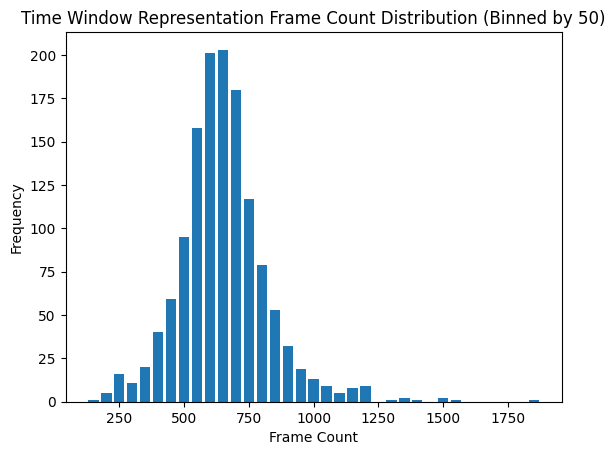

In [50]:
binned2_time_window = time_window_histogram.groupby(np.round(time_window_histogram.index.astype(float) / 50) * 50).sum()
binned2_time_window.index = binned2_time_window.index.astype(int)
plt.bar(binned2_time_window.index, binned2_time_window.values, width=40)
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.title("Time Window Representation Frame Count Distribution (Binned by 50)")
plt.show()

In [41]:
binned2_time_window = binned2_time_window.sort_values(ascending=False)
binned2_time_window

650     203
600     201
700     180
550     158
750     117
500      95
800      79
450      59
850      53
400      40
900      32
350      20
950      19
250      16
1000     13
300      11
1050      9
1200      9
1150      8
200       5
1100      5
1500      2
1350      2
1550      1
150       1
1400      1
1300      1
1850      1
Name: 0, dtype: int64

In [73]:
time_window_frame_counts_binned2 = np.repeat(
    binned2_time_window.index.astype(int).values,
    binned2_time_window.values
)
p90_time_window_binned2 = np.percentile(time_window_frame_counts_binned2, 90)
p95_time_window_binned2 = np.percentile(time_window_frame_counts_binned2, 95)

print("90th percentile binned with 50:", p90_time_window_binned2)
print("95th percentile binned with 50:", p95_time_window_binned2)

90th percentile binned with 50: 850.0
95th percentile binned with 50: 950.0


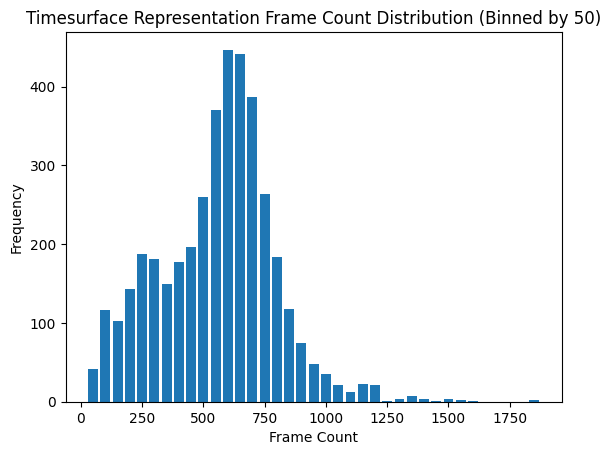

In [51]:
binned2_timesurface = timsurface_histogram.groupby(np.round(timsurface_histogram.index.astype(float) / 50) * 50).sum()
binned2_timesurface.index = binned2_timesurface.index.astype(int)
plt.bar(binned2_timesurface.index, binned2_timesurface.values, width=40)
plt.xlabel("Frame Count")
plt.ylabel("Frequency")
plt.title("Timesurface Representation Frame Count Distribution (Binned by 50)")
plt.show()

In [42]:
binned2_timesurface = binned2_timesurface.sort_values(ascending=False)
binned2_timesurface

600     447
650     442
700     387
550     370
750     264
500     260
450     196
250     187
800     184
300     181
400     177
350     149
200     143
850     118
100     116
150     102
900      74
950      48
50       41
1000     35
1150     23
1050     21
1200     21
1100     12
1350      7
1400      4
1500      4
1300      3
1550      2
1850      2
1250      1
1450      1
1600      1
Name: 0, dtype: int64

In [ ]:
spike_count_histogram

504      4
579     11
671      8
726      3
865      2
        ..
274      2
1151     1
901      1
371      1
209      1
Name: 0, Length: 895, dtype: int64

In [74]:
timesurface_frame_counts_binned2 = np.repeat(
    binned2_timesurface.index.astype(int).values,
    binned2_timesurface.values
)
p90_timesurface_binned2 = np.percentile(timesurface_frame_counts_binned2, 90)
p95_timesurface_binned2 = np.percentile(timesurface_frame_counts_binned2, 95)

print("90th percentile binned with 50:", p90_timesurface_binned2)
print("95th percentile binned with 50:", p95_timesurface_binned2)

90th percentile binned with 50: 800.0
95th percentile binned with 50: 900.0
